### Explore protein matches
### Julian Moran
### 2026-02-16

In [124]:
import logging
import os

from adjustText import adjust_text
from dotenv import load_dotenv
from gprofiler import GProfiler
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

# Env
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

In [102]:
# ============================================================
#                              Args
# ============================================================

args = {
    "data_file_protein_matches_filtExtra": f"{INSTALL_PATH}/results/explore_aJain_iei_pipeline/defense_proteins_filtExtra_n=34.tsv",
    "data_file_protein_matches_filt": f"{INSTALL_PATH}/results/explore_aJain_iei_pipeline/defense_proteins_filt_n=904.tsv",
    "data_dir_alignments": f"{INSTALL_PATH}/data_sync/rcsb_pdb_align",
    "col_pm_cluster_id": "cluster_id",
    "col_pm_defProt_id": "defense_system_protein_id",
    "col_pm_hsProt_id": "protein_id",
    "col_al_identity": "Identity",
    "alignment_cols_meta": ["Entry", "Chain", "Sequence Length", "Modeled Residues"],
    "alignment_cols_align": ["RMSD", "TM-score", "Identity", "Aligned Residues"],
    "out_path": f"{INSTALL_PATH}/results/explore_protein_matches"
}

In [93]:
# ============================================================
#                               In
# ============================================================

pl.Config.set_tbl_rows(10)

df_protein_matches_34 = pl.read_csv(
    args["data_file_protein_matches_filtExtra"],
    separator="\t",
    has_header=True
)

df_protein_matches_904 = pl.read_csv(
    args["data_file_protein_matches_filt"],
    separator="\t",
    has_header=True
)

alignment_metrics = {}
for file_path in list(Path(args["data_dir_alignments"]).glob("*.tsv")):
    key = (file_path.name
        .replace(".tsv", "")
        .replace("AF-", "")
        .replace("-F1", "")
    )
    alignment_metrics[key] = pl.read_csv(
        file_path,
        separator="\t",
        has_header=True,
        schema_overrides={
            "RMSD": pl.Float64,
            "TM-score": pl.Float64,
            "Aligned Residues": pl.Int64
        },
        null_values=["-", "- "]
    )

df_protein_matches_34

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_difference
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""A0A2S1ZR87""",0.0,1,0.147,1035,859,0.0,48,1055,3,1037,1.0510e-32,586,"""unreviewed""","""A0A2S1ZR87_HUMAN""","""Structural maintenance of chro…","""SMC6""","""Homo sapiens (Human)""",null,null,"""SMC6""",null,null,"""DNA recombination [GO:0006310]…","""chromosome, centromeric region…","""chromosome, centromeric region…","""ATP binding [GO:0005524]; ATP …","""GO:0000775; GO:0000781; GO:000…",null,"""3.40.50.300:FF:000959; structu…","""3.40.50.300; P-loop containing…","""IPR027417; P-loop_NTPase.;""IPR…","""PTHR19306; STRUCTURAL MAINTENA…","""PF13476; AAA_23; 1.;""",null,null,"""NP_001135758.1; NM_001142286.2…","""48.0..1055.0""",1008,1091,"""50..257""",100.0,20.63,92.39,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""","""3.0..1037.0""",1035,1071,"""5..225""",100.0,21.35,96.64,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""",0.981668,1008.0,0.941176,"""No""",0.018332
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""Q8IY18""",0.0,1,0.136,1032,867,0.0,53,1056,3,1034,8.2640e-31,530,"""reviewed""","""SMC5_HUMAN""","""Structural maintenance of chro…","""SMC5 KIAA0594 SMC5L1""","""Homo sapiens (Human)""",null,null,"""SMC5""","""KIAA0594 SMC5L1""","""UP000005640: Chromosome 9""","""cell division [GO:0051301]; ce…","""cell junction [GO:0030054]; ch…","""cell junction [GO:0030054]; ch…","""ATP binding [GO:0005524]; ATP …","""GO:0000217; GO:0000722; GO:000…",null,"""3.40.50.300:FF:000793; Structu…","""3.40.50.300; P-loop containing…","""IPR027417; P-loop_NTPase.;""IPR…","""PTHR45916; STRUCTURAL MAINTENA…","""PF13476; AAA_23; 1.;""",null,null,"""NP_055925.2; NM_015110.4.;""","""53.0..1056.0""",1004,1101,null,null,null,null,null,null,"""3.0..1034.0""",1032,1071,"""5..225""",100.0,21.41,96.36,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""",0.972752,1004.0,0.937442,"""No""",0.027248
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""Q96SB8""",0.0,1,0.141,1035,865,0.0,48,1055,3,

In [94]:
alignment_metrics["B8DW98-B0AZQ4"]

Entry,Chain,RMSD,TM-score,Identity,Aligned Residues,Sequence Length,Modeled Residues
str,str,f64,f64,str,i64,i64,i64
"""AF-B8DW98-F1""","""A""",null,null,null,null,1165,1165
"""AF-B0AZQ4-F1""","""A""",7.25,0.34,"""10% """,219,1217,1217


In [95]:
# ============================================================
#                             Summary
# ============================================================

def summarise_protein_matches(
    df: pl.DataFrame
) -> pl.DataFrame:

    logger.info(f"N protein matches: {len(df)}")

    unique_clusters = df[args["col_pm_cluster_id"]].unique()
    logger.info(f"N unique clusters: {len(unique_clusters)}")

    unique_protein_pairs = df.unique(
        subset=[args["col_pm_defProt_id"], args["col_pm_hsProt_id"], args["col_pm_cluster_id"]]
    ).sort(args["col_pm_cluster_id"])

    # unique_protein_pairs = df[
    #     [args["col_pm_defProt_id"], args["col_pm_hsProt_id"], args["col_pm_cluster_id"]]
    # ].unique().sort("cluster_id")

    logger.info(f"N unique protein pairs: {len(unique_protein_pairs)}")
    logger.info(unique_clusters)

    return unique_protein_pairs

unique_protein_pairs_34 = summarise_protein_matches(df_protein_matches_34)
unique_protein_pairs_904 = summarise_protein_matches(df_protein_matches_904)

INFO:__main__:N protein matches: 34
INFO:__main__:N unique clusters: 3
INFO:__main__:N unique protein pairs: 34
INFO:__main__:shape: (3,)
Series: 'cluster_id' [str]
[
	"A0A6I4ZMH2"
	"A0A1W9R9X2"
	"A0A4P9X374"
]
INFO:__main__:N protein matches: 904
INFO:__main__:N unique clusters: 17
INFO:__main__:N unique protein pairs: 297
INFO:__main__:shape: (17,)
Series: 'cluster_id' [str]
[
	"A0A2S9BGI2"
	"A0A1W9R9X2"
	"A0A6C0LXL7"
	"A0A7S4UXI5"
	"A0A4Q9LAP2"
	…
	"T0L9T3"
	"A0A6I4ZMH2"
	"A0A480PGP1"
	"E4U3I0"
	"A0A2E7NAI8"
]


In [97]:
pl.Config.set_tbl_rows(10)

unique_protein_pairs_34

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene,Protein_length_difference
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str,f64
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""Q8IY18""",0.0,1,0.136,1032,867,0.0,53,1056,3,1034,8.2640e-31,530,"""reviewed""","""SMC5_HUMAN""","""Structural maintenance of chro…","""SMC5 KIAA0594 SMC5L1""","""Homo sapiens (Human)""",null,null,"""SMC5""","""KIAA0594 SMC5L1""","""UP000005640: Chromosome 9""","""cell division [GO:0051301]; ce…","""cell junction [GO:0030054]; ch…","""cell junction [GO:0030054]; ch…","""ATP binding [GO:0005524]; ATP …","""GO:0000217; GO:0000722; GO:000…",null,"""3.40.50.300:FF:000793; Structu…","""3.40.50.300; P-loop containing…","""IPR027417; P-loop_NTPase.;""IPR…","""PTHR45916; STRUCTURAL MAINTENA…","""PF13476; AAA_23; 1.;""",null,null,"""NP_055925.2; NM_015110.4.;""","""53.0..1056.0""",1004,1101,null,null,null,null,null,null,"""3.0..1034.0""",1032,1071,"""5..225""",100.0,21.41,96.36,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""",0.972752,1004.0,0.937442,"""No""",0.027248
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""A0A2S1ZR79""",0.0,1,0.148,1035,858,0.0,48,1055,3,1037,6.6680e-33,594,"""unreviewed""","""A0A2S1ZR79_HUMAN""","""Structural maintenance of chro…","""SMC6""","""Homo sapiens (Human)""",null,null,"""SMC6""",null,null,"""DNA recombination [GO:0006310]…","""chromosome, telomeric region […","""chromosome, telomeric region […","""ATP binding [GO:0005524]; ATP …","""GO:0000781; GO:0005524; GO:000…",null,"""3.40.50.300:FF:000959; structu…","""3.40.50.300; P-loop containing…","""IPR027417; P-loop_NTPase.;""IPR…","""PTHR19306; STRUCTURAL MAINTENA…","""PF13476; AAA_23; 1.;""",null,null,null,"""48.0..1055.0""",1008,1091,"""50..257""",100.0,20.63,92.39,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""","""3.0..1037.0""",1035,1071,"""5..225""",100.0,21.35,96.64,"""['Rad50/SbcC-type AAA']""","""['ECO:0000259|Pfam:PF13476']""",0.981668,1008.0,0.941176,"""No""",0.018332
"""WP_017417305.1""","""Wadjet""","""Wadjet_III""","""Bacillus amyloliquefaciens,Bac…","""GCF_013875015_NZ_CP059405_Wadj…","""GCF_003432425.1_NZ_CP023075_00…","""GCF_003432425.1_NZ_CP023075_00…",13,190,"""A0A411A3U6""","""A0A1W9R9X2""","""A0A1W9R9X2""","""A0A2S1ZR87""",0.0,1,0.147,1035,859,0.0,48,1055,3,1037,1.0510e-32,586,"""unre

In [96]:
pl.Config.set_tbl_rows(10)

unique_protein_pairs_904

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,GRIID_gene
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,str
"""WP_000434627.1""","""Eleos""","""Eleos""","""Escherichia coli""","""GCF_016776005_NZ_CP068823_Eleo…","""GCF_016775985.1_NZ_CP068827_02…","""GCF_020883255.1_NZ_CP086618_00…",27,176,"""Q9RFR9""","""A0A1I1GWW8""","""A0A1I1GWW8""","""O95140""",1.2200e-96,1,0.116,703,497,0.0,29,731,4,566,3.1020e-12,224,"""reviewed""","""MFN2_HUMAN""","""Mitofusin-2 (EC 3.6.5.-) (Tran…","""MFN2 CPRP1 KIAA0214""","""Homo sapiens (Human)""",null,null,"""MFN2""","""CPRP1 KIAA0214""","""UP000005640: Chromosome 1""","""aerobic respiration [GO:000906…","""cytosol [GO:0005829]; microtub…","""cytosol [GO:0005829]; microtub…","""GTP binding [GO:0005525]; GTPa…","""GO:0001825; GO:0003924; GO:000…","""cd09912; DLP_2; 1.;""","""1.20.5.110:FF:000012; Mitofusi…","""1.20.5.110; -; 1.;""3.40.50.300…","""IPR045063; Dynamin_N.;""IPR0068…","""PTHR10465:SF1; MITOFUSIN-2; 1.…","""PF00350; Dynamin_N; 1.;""PF0479…","""PS51718; G_DYNAMIN_2; 1.;""",null,"""NP_001121132.1; NM_001127660.2…","""29.0..731.0""",703,757,"""93..342""",100.0,35.56,92.87,"""['Dynamin-type G']""","""['ECO:0000255|PROSITE-ProRule:…","""4.0..566.0""",563,577,"""212..555""",100.0,61.1,97.57,"""['Dynamin-like helical']""","""['ECO:0000259|Pfam:PF18709']""",0.762219,563.0,0.975737,"""Yes"""
"""WP_074585635.1""","""Eleos""","""Eleos""","""Bacillus mobilis,Bacillus cere…","""GCF_021655235_NZ_AP022971_Eleo…","""GCF_021655175.1_NZ_AP022953_00…","""GCF_021655235.1_NZ_AP022971_00…",14,189,"""A0A1Y6A5H7""","""A0A1I1GWW8""","""A0A1I1GWW8""","""A0A6Q8PGA3""",1.2200e-96,1,0.129,647,451,0.0,42,688,5,523,6.6020e-10,167,"""unreviewed""","""A0A6Q8PGA3_HUMAN""","""Mitofusin 2""","""MFN2""","""Homo sapiens (Human)""",null,null,"""MFN2""",null,"""UP000005640: Chromosome 1""","""mitochondrial fusion [GO:00080…","""mitochondrial outer membrane […","""mitochondrial outer membrane […","""GTP binding [GO:0005525]; GTPa…","""GO:0003924; GO:0005525; GO:000…","""cd09912; DLP_2; 1.;""","""3.40.50.300:FF:000214; Mitofus…","""3.40.50.300; P-loop containing…","""IPR045063; Dynamin_N.;""IPR0068…","""PTHR10465:SF1; MITOFUSIN-2; 1.…","""PF00350; Dynamin_N; 1.;""PF0479…","""PS51718; G_DYNAMIN_2; 1.;""",null,null,"""42.0..688.0""",647,690,"""93..342""",100.0,38.64,93.77,"""['Dynamin-type G']""","""['ECO:0000259|PROSITE:PS51718'…","""5.0..523.0""",519,579,"""53..185""",100.0,25.63,89.64,"""['G']""","""['ECO:0000259|Pfam:PF01926']""",0.83913,519.0,0.896373,"""Yes"""
"""WP_000434627.1""","""Eleos""","""Eleos""","""Escherichia coli""","""GCF_016776005_NZ_CP068823_Eleo…","""GCF_016775985.1_NZ_CP068827_02…","""GCF_020883255.1_NZ_CP086618_00…",27,176,"""Q9RFR9""","""A0A1I1GWW8""","""A0A1I1GWW8""","""A0A6Q8PFJ4

In [125]:
# ============================================================
#                           G-profiler
# ============================================================

gp = GProfiler(return_dataframe=True)
res = gp.profile(
    organism="hsapiens",
    query=unique_protein_pairs_904[args["col_pm_hsProt_id"]].to_list()
)

res.head(10).to_csv(
    f"{args['out_path']}/g_profiler_top10.tsv",
    sep="\t",
    header=True
)

res

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:MF,GO:0016887,ATP hydrolysis activity,5.320583e-14,True,"""Catalysis of the reaction: ATP + H2O = ADP + ...",411,19,12,20246,0.631579,0.029197,query_1,"[GO:0017111, GO:0140657]"
1,GO:MF,GO:0140657,ATP-dependent activity,8.176689e-12,True,"""A molecular function characterized by the cou...",626,19,12,20246,0.631579,0.019169,query_1,[GO:0003674]
2,GO:MF,GO:0017111,ribonucleoside triphosphate phosphatase activity,5.900987e-10,True,"""Catalysis of the reaction: a ribonucleoside t...",1201,19,13,20246,0.684211,0.010824,query_1,[GO:0016462]
3,GO:MF,GO:0016462,pyrophosphatase activity,1.096287e-09,True,"""Catalysis of the hydrolysis of a pyrophosphat...",1261,19,13,20246,0.684211,0.010309,query_1,[GO:0016818]
4,GO:MF,GO:0016817,"hydrolase activity, acting on acid anhydrides",1.107374e-09,True,"""Catalysis of the hydrolysis of any acid anhyd...",1262,19,13,20246,0.684211,0.010301,query_1,[GO:0016787]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,GO:BP,GO:0034085,establishment of sister chromatid cohesion,3.879794e-02,True,"""The process in which the sister chromatids of...",9,18,2,21026,0.111111,0.222222,query_1,"[GO:0007062, GO:0022402]"
111,REAC,REAC:R-HSA-68877,Mitotic Prometaphase,3.934131e-02,True,Mitotic Prometaphase,200,15,4,11004,0.266667,0.020000,query_1,[REAC:R-HSA-68886]
112,REAC,REAC:R-HSA-68884,Mitotic Telophase/Cytokinesis,4.271284e-02,True,Mitotic Telophase/Cytokinesis,13,15,2,11004,0.133333,0.153846,query_1,[REAC:R-HSA-68886]
113,REAC,REAC:R-HSA-1221632,Meiotic synapsis,4.322062e-02,True,Meiotic synapsis,76,15,3,11004,0.200000,0.039474,query_1,[REAC:R-HSA-1500620]


In [99]:
# ============================================================
#                    Wrangle alignment metrics
# ============================================================

def wrangle_alignment_data(
    df: pl.DataFrame,
    cols_meta: List,
    cols_align: List,
    row_prefix_first: str="Bacterial ",
    row_prefix_second: str="Human "
) -> pl.DataFrame:
    
    row_first = df.row(0, named=True)
    row_second = df.row(1, named=True)
    wrangled = {}

    for col in cols_meta:
        wrangled[f"{row_prefix_first}{col}"] = row_first[col]
        wrangled[f"{row_prefix_second}{col}"] = row_second[col]

    for col in cols_align:
        wrangled[col] = row_second[col]

    return pl.DataFrame([wrangled])

df_alignment_metrics = pl.concat(
    [wrangle_alignment_data(
            df,
            cols_meta=args["alignment_cols_meta"],
            cols_align=args["alignment_cols_align"]
        ) for df in alignment_metrics.values()],
    how="vertical"
)

df_alignment_metrics = df_alignment_metrics.with_columns(
    (
        pl.col(args["col_al_identity"])
        .str.strip_chars()
        .str.replace("%", "")
        .cast(pl.Float64) / 100
    ).alias(args["col_al_identity"])
)

df_alignment_metrics

Bacterial Entry,Human Entry,Bacterial Chain,Human Chain,Bacterial Sequence Length,Human Sequence Length,Bacterial Modeled Residues,Human Modeled Residues,RMSD,TM-score,Identity,Aligned Residues
str,str,str,str,i64,i64,i64,i64,f64,f64,f64,i64
"""AF-B8DW98-F1""","""AF-B0AZQ4-F1""","""A""","""A""",1165,1217,1165,1217,7.25,0.34,0.1,219
"""AF-A0A5B9Y4K1-F1""","""AF-Q6ICS7-F1""","""A""","""A""",381,391,381,391,2.72,0.68,0.19,265
"""AF-F6FPD4-F1""","""AF-Q9H4L7-F1""","""A""","""A""",1005,1026,1005,1026,4.23,0.47,0.23,443
"""AF-A0A806FWR7-F1""","""AF-B3KMB1-F1""","""A""","""A""",1165,1197,1165,1197,6.79,0.33,0.09,254
"""AF-A0A411A3U6-F1""","""AF-A0A2S1ZR87-F1""","""A""","""A""",1071,1091,1071,1091,7.17,0.34,0.12,202
…,…,…,…,…,…,…,…,…,…,…,…
"""AF-A0A1A9K893-F1""","""AF-A0A7P0T9U2-F1""","""A""","""A""",328,298,328,298,3.45,0.57,0.21,188
"""AF-A0A2K8UJG1-F1""","""AF-A0A7P0TA11-F1""","""A""","""A""",284,239,284,239,2.7,0.64,0.32,186
"""AF-B8DW98-F1""","""AF-A8K984-F1""","""A""","""A""",1165,1197,1165,1197,7.79,0.36,0.1,224


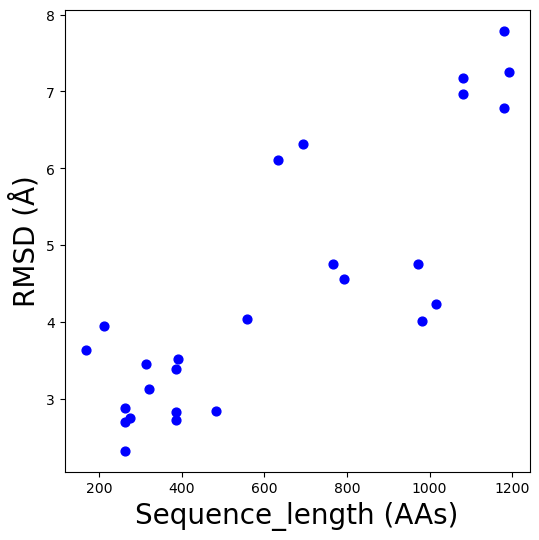

In [116]:
# ============================================================
#                           RMSD v. sequence length
# ============================================================

def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_rmsd_vs_mean_length(
    df: pl.DataFrame,
    plot_title: str = "",
    title_font_size: int = 14,
    y_axis_label: str = "RMSD (Å)",
    x_axis_label: str = "Sequence_length (AAs)",
    dot_size: float = 40,
    dot_alpha: float = 1.0,
    dot_colour: str = "blue",
    axis_label_font_size: int = 20,
    ann_font_size: int = 14,
    label_best_n: int = 3,
    dims: Tuple[int, int] = (6, 6),
    out_path = None,
) -> None:

    df_plot = df.with_columns(
        (
            (pl.col("Bacterial Sequence Length") + pl.col("Human Sequence Length")) / 2
        ).alias("mean_length")
    )

    x = df_plot["mean_length"].to_numpy()
    y = df_plot["RMSD"].to_numpy()

    fig, ax = plt.subplots(figsize=dims)
    ax.scatter(x, y, s=dot_size, c=dot_colour, alpha=dot_alpha)

    ax.set_title(plot_title, fontsize=title_font_size)
    ax.set_xlabel(x_axis_label, fontsize=axis_label_font_size)
    ax.set_ylabel(y_axis_label, fontsize=axis_label_font_size)

    best = df_plot.sort("RMSD").head(label_best_n)
    # texts = []
    # for row in best.iter_rows(named=True):
    #     texts.append(
    #         ax.annotate(
    #             row["Human Entry"],
    #             (row["mean_length"], row["RMSD"]),
    #             fontsize=ann_font_size,
    #         )
    #     )
    # # adjust_text(texts, ax=ax)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_rmsd_vs_mean_length(
    df_alignment_metrics,
    out_path=f"{args['out_path']}/RMSD_seqLength_n={len(df_alignment_metrics)}"
)

In [77]:
args.keys()

dict_keys(['data_file_protein_matches_filtExtra', 'data_file_protein_matches_filt', 'data_dir_alignments', 'col_pm_cluster_id', 'col_pm_defProt_id', 'col_pm_hsProt_id', 'col_al_identify', 'alignment_cols_meta', 'alignment_cols_align'])